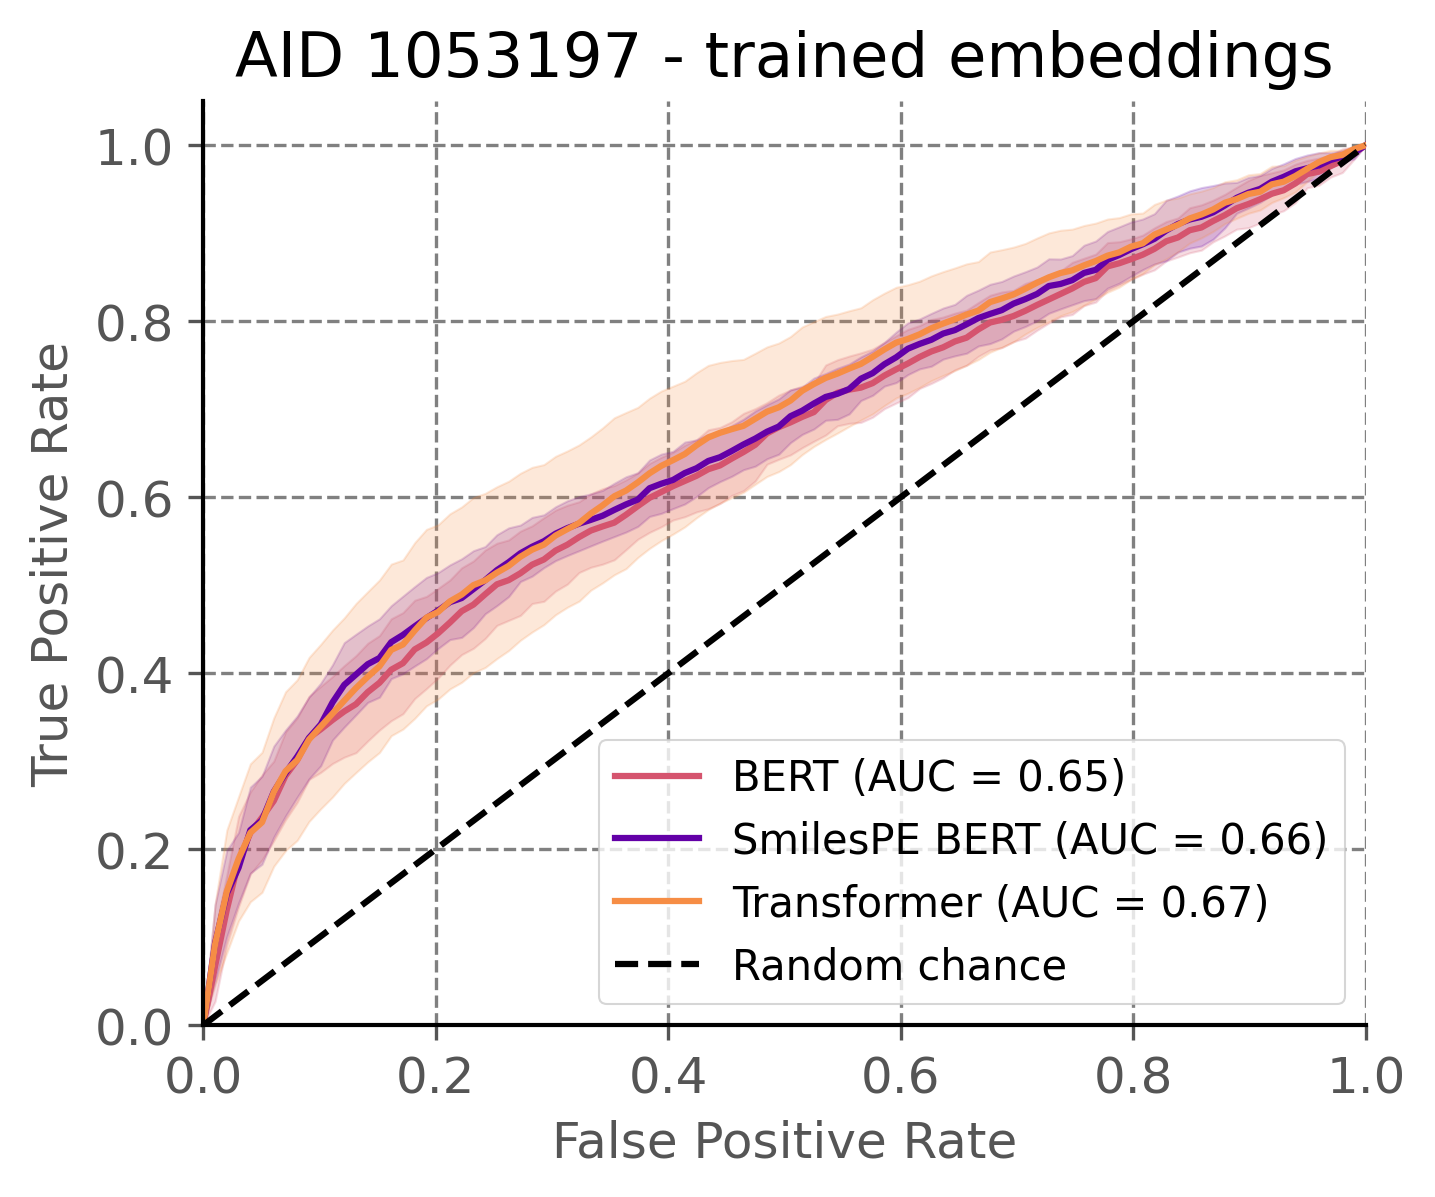

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import RocCurveDisplay, roc_curve, roc_auc_score, auc
import seaborn as sns

plt.style.use('ggplot')
plt.style.use('ggplot')
plt.rcParams.update({
    'axes.edgecolor': 'black', 
    'axes.facecolor': 'white',
    'grid.color': 'gray', 
    'grid.linestyle': '--',
    'grid.alpha': 1, 
    'axes.grid': True,
    'axes.spines.top': False,
    'axes.spines.right': False
})

def process_roc(file, color, label_prefix):
    content = np.load(file)
    accs, labs, preds = content['accs'], content['labs'], content['preds']

    aucs, tprs = [], []
    mean_fpr = np.linspace(0, 1, 100)

    for fold in range(10):
        labs_k = labs[0][fold]#[0,:]
        preds_k = preds[0][fold]#[0,:]
        fpr, tpr, _ = roc_curve(labs_k, preds_k)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(labs_k, preds_k))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(mean_fpr, mean_tpr, color=color, label=f'{label_prefix} (AUC = {mean_auc:.2f})')
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

# Plotting ROC curves for both files
my_dpi = 300
plt.figure(figsize=(1500/my_dpi, 1200/my_dpi), dpi=my_dpi)

palette = sns.color_palette("plasma", 10)

process_roc("Experiments_results/res_bert_1053197.npz", 
            color=palette[5], label_prefix='BERT')
process_roc("Experiments_results/res_bert_spe_1053197.npz", 
            color=palette[1], label_prefix='SmilesPE BERT')
process_roc("Experiments_results/res_transformer_1053197.npz", 
            color=palette[7], label_prefix='Transformer')



plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AID 1053197 - trained embeddings', fontsize = 15)
plt.legend(loc='lower right', prop={'size': 10})
plt.tick_params(axis='both', which='major', labelsize=12)

plt.show()

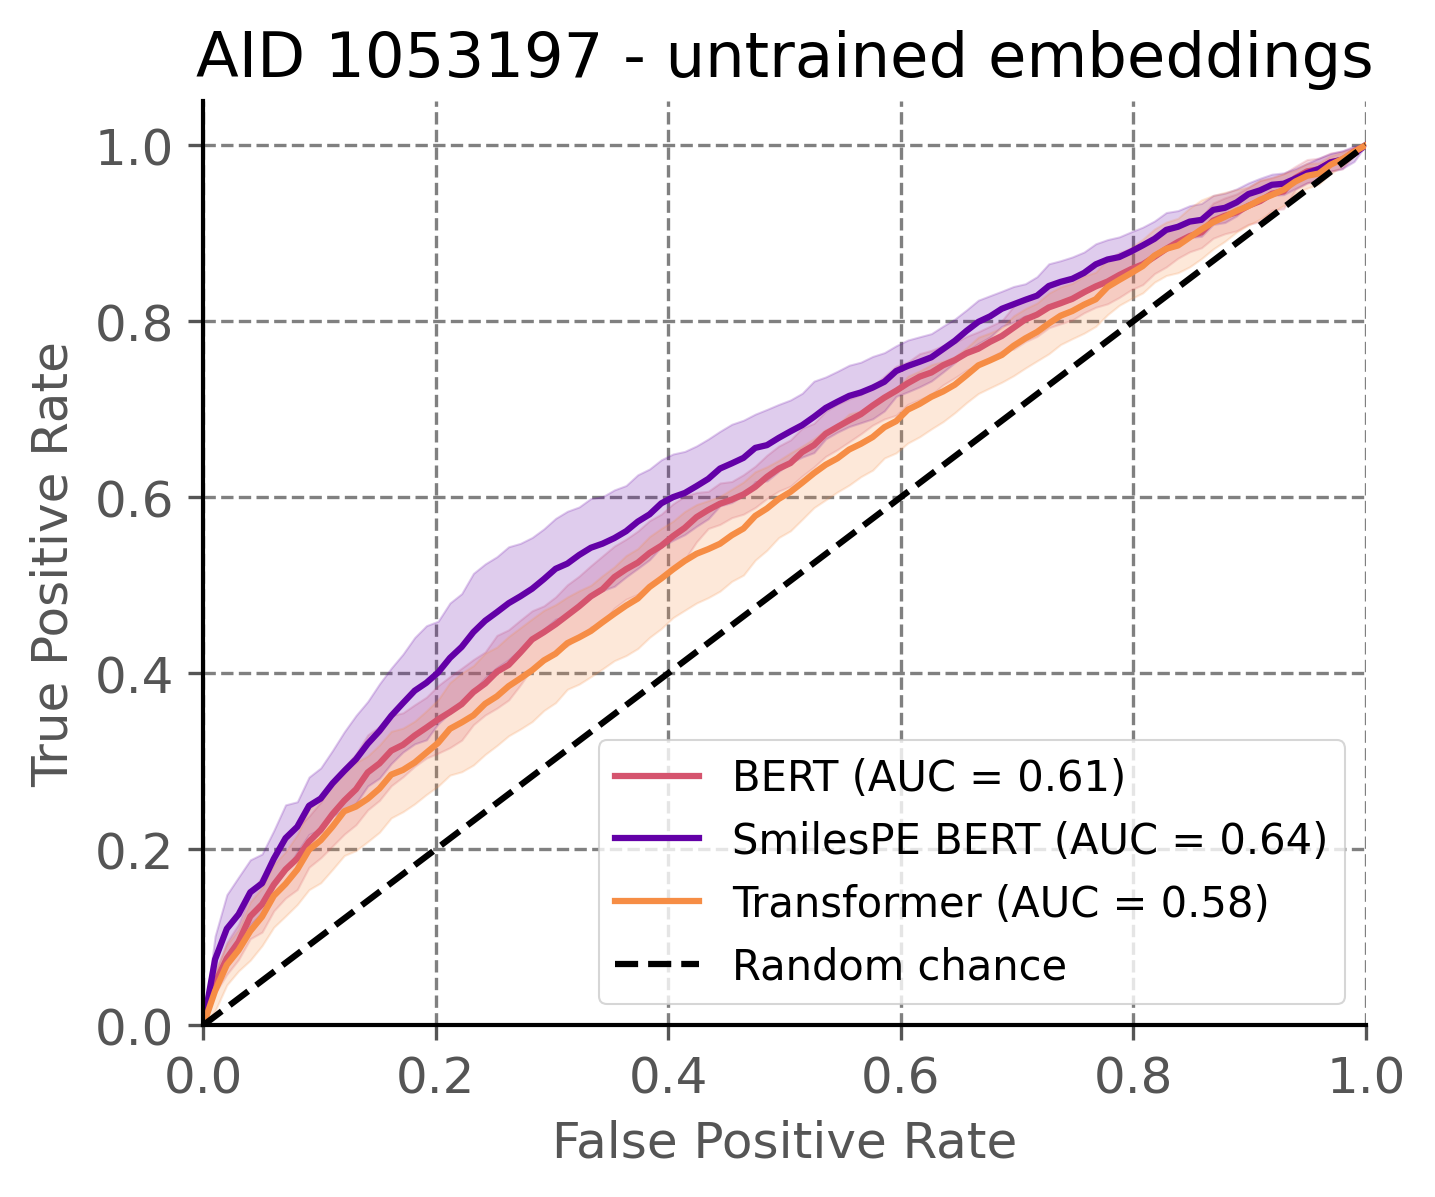

In [3]:
def process_roc(file, color, label_prefix):
    content = np.load(file)
    accs, labs, preds = content['accs'], content['labs'], content['preds']

    aucs, tprs = [], []
    mean_fpr = np.linspace(0, 1, 100)

    for fold in range(10):
        labs_k = labs[0][fold]#[0,:]
        preds_k = preds[0][fold]#[0,:]
        fpr, tpr, _ = roc_curve(labs_k, preds_k)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(labs_k, preds_k))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(mean_fpr, mean_tpr, color=color, label=f'{label_prefix} (AUC = {mean_auc:.2f})')
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

# Plotting ROC curves for both files
my_dpi = 300
plt.figure(figsize=(1500/my_dpi, 1200/my_dpi), dpi=my_dpi)

palette = sns.color_palette("plasma", 10)


process_roc("Experiments_results/res_bert_1053197_untrained.npz", 
            color=palette[5], label_prefix='BERT')
process_roc("Experiments_results/res_bert_spe_1053197_untrained.npz", 
                color=palette[1], label_prefix='SmilesPE BERT')
process_roc("Experiments_results/res_transformer_1053197_untrained.npz", 
                color=palette[7], label_prefix='Transformer')



plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AID 1053197 - untrained embeddings', fontsize = 15)
plt.legend(loc='lower right', prop={'size': 10})
plt.tick_params(axis='both', which='major', labelsize=12)

plt.show()

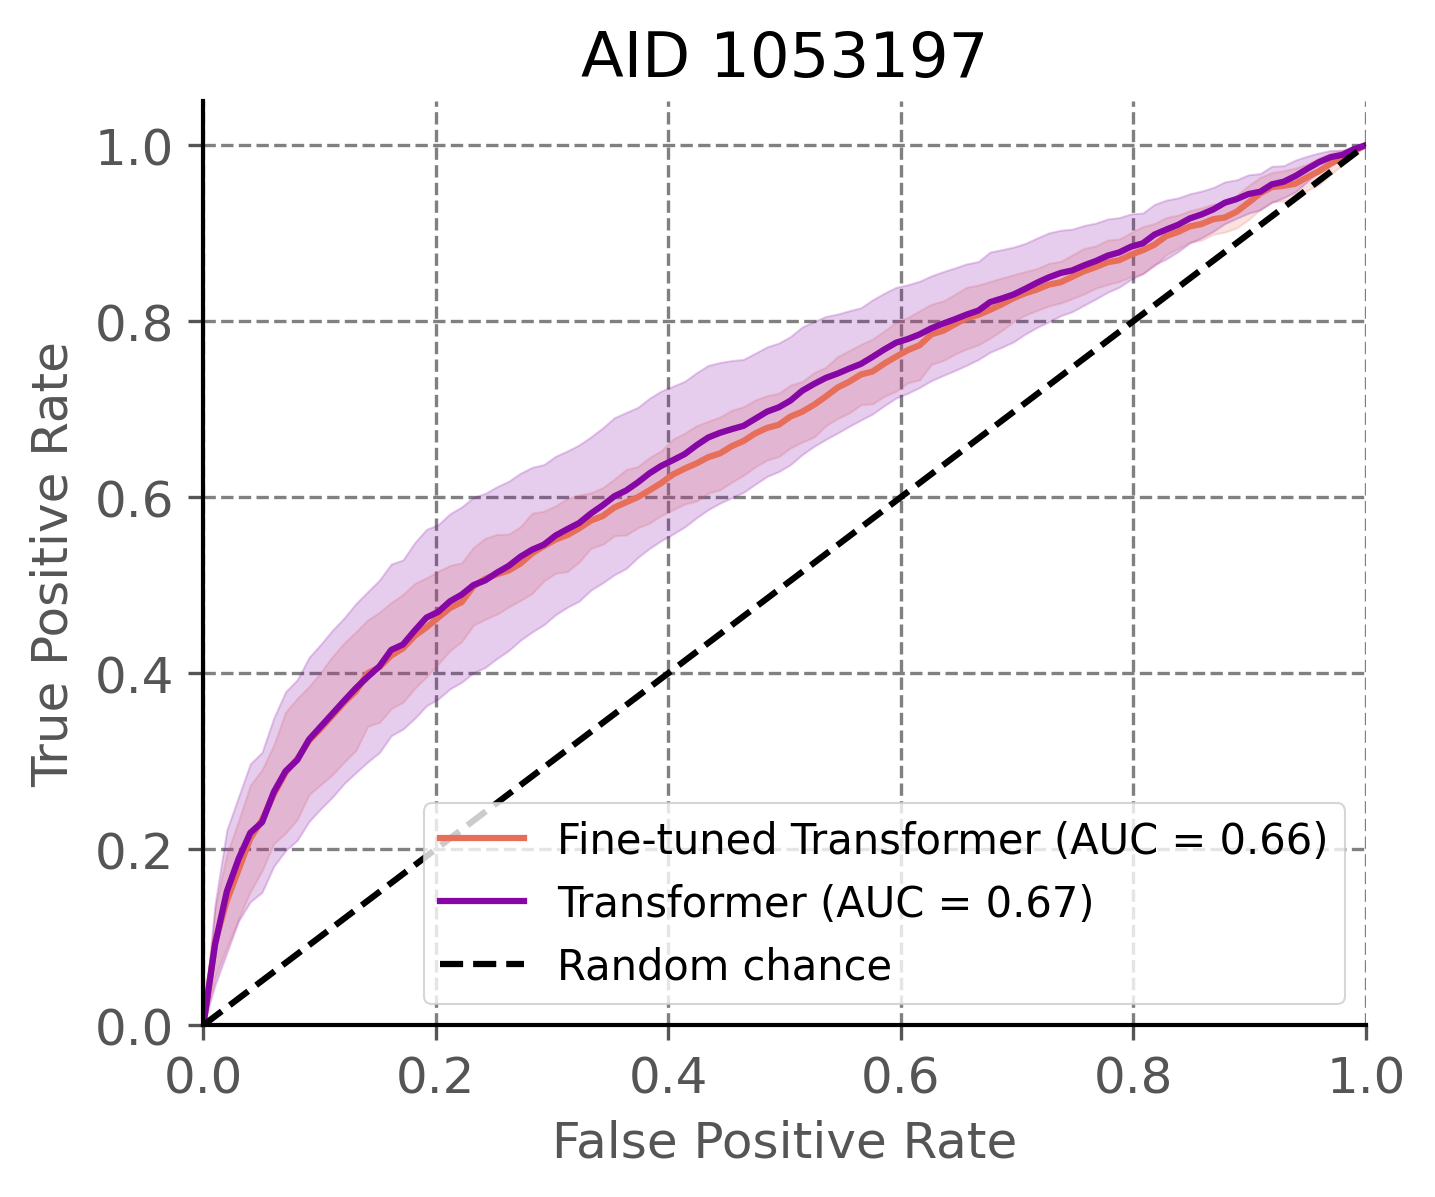

In [4]:
def process_roc(file, color, label_prefix):
    content = np.load(file)
    accs, labs, preds = content['accs'], content['labs'], content['preds']

    aucs, tprs = [], []
    mean_fpr = np.linspace(0, 1, 100)

    for fold in range(10):
        labs_k = labs[0][fold]#[0,:]
        preds_k = preds[0][fold]#[0,:]
        fpr, tpr, _ = roc_curve(labs_k, preds_k)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(labs_k, preds_k))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(mean_fpr, mean_tpr, color=color, label=f'{label_prefix} (AUC = {mean_auc:.2f})')
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

# Plotting ROC curves for both files
my_dpi = 300
plt.figure(figsize=(1500/my_dpi, 1200/my_dpi), dpi=my_dpi)

palette = sns.color_palette("plasma", 10)

process_roc("Experiments_results/res_finetuned_transformer_1053197.npz", 
            color=palette[6], label_prefix='Fine-tuned Transformer')
process_roc("Experiments_results/res_transformer_1053197.npz", 
            color=palette[2], label_prefix='Transformer')


plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AID 1053197', fontsize = 15)
plt.legend(loc='lower right', prop={'size': 10})
plt.tick_params(axis='both', which='major', labelsize=12)

plt.show()

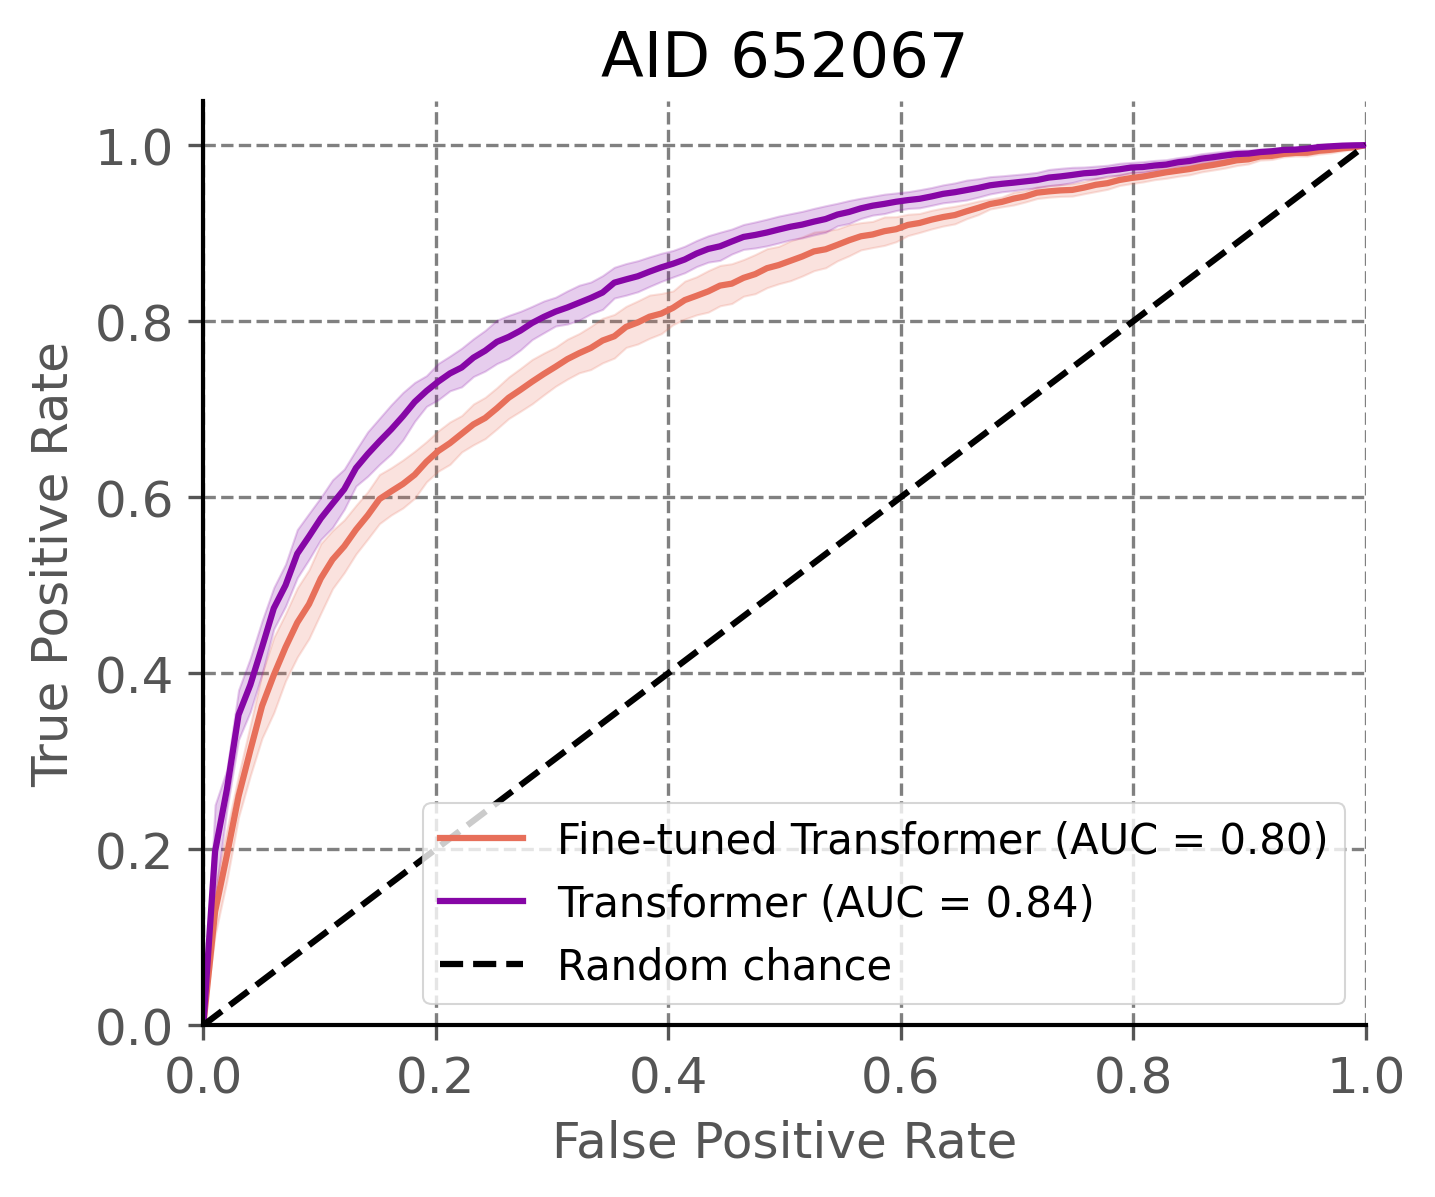

In [5]:
def process_roc(file, color, label_prefix):
    content = np.load(file)
    accs, labs, preds = content['accs'], content['labs'], content['preds']

    aucs, tprs = [], []
    mean_fpr = np.linspace(0, 1, 100)

    for fold in range(10):
        labs_k = labs[0][fold]#[0,:]
        preds_k = preds[0][fold]#[0,:]
        fpr, tpr, _ = roc_curve(labs_k, preds_k)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(labs_k, preds_k))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(mean_fpr, mean_tpr, color=color, label=f'{label_prefix} (AUC = {mean_auc:.2f})')
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

# Plotting ROC curves for both files
my_dpi = 300
plt.figure(figsize=(1500/my_dpi, 1200/my_dpi), dpi=my_dpi)

palette = sns.color_palette("plasma", 10)

process_roc("Experiments_results/res_finetuned_transformer_652067.npz", 
            color=palette[6], label_prefix='Fine-tuned Transformer')
process_roc("Experiments_results/res_transformer_652067.npz", 
            color=palette[2], label_prefix='Transformer')


plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AID 652067', fontsize = 15)
plt.legend(loc='lower right', prop={'size': 10})
plt.tick_params(axis='both', which='major', labelsize=12)

plt.show()

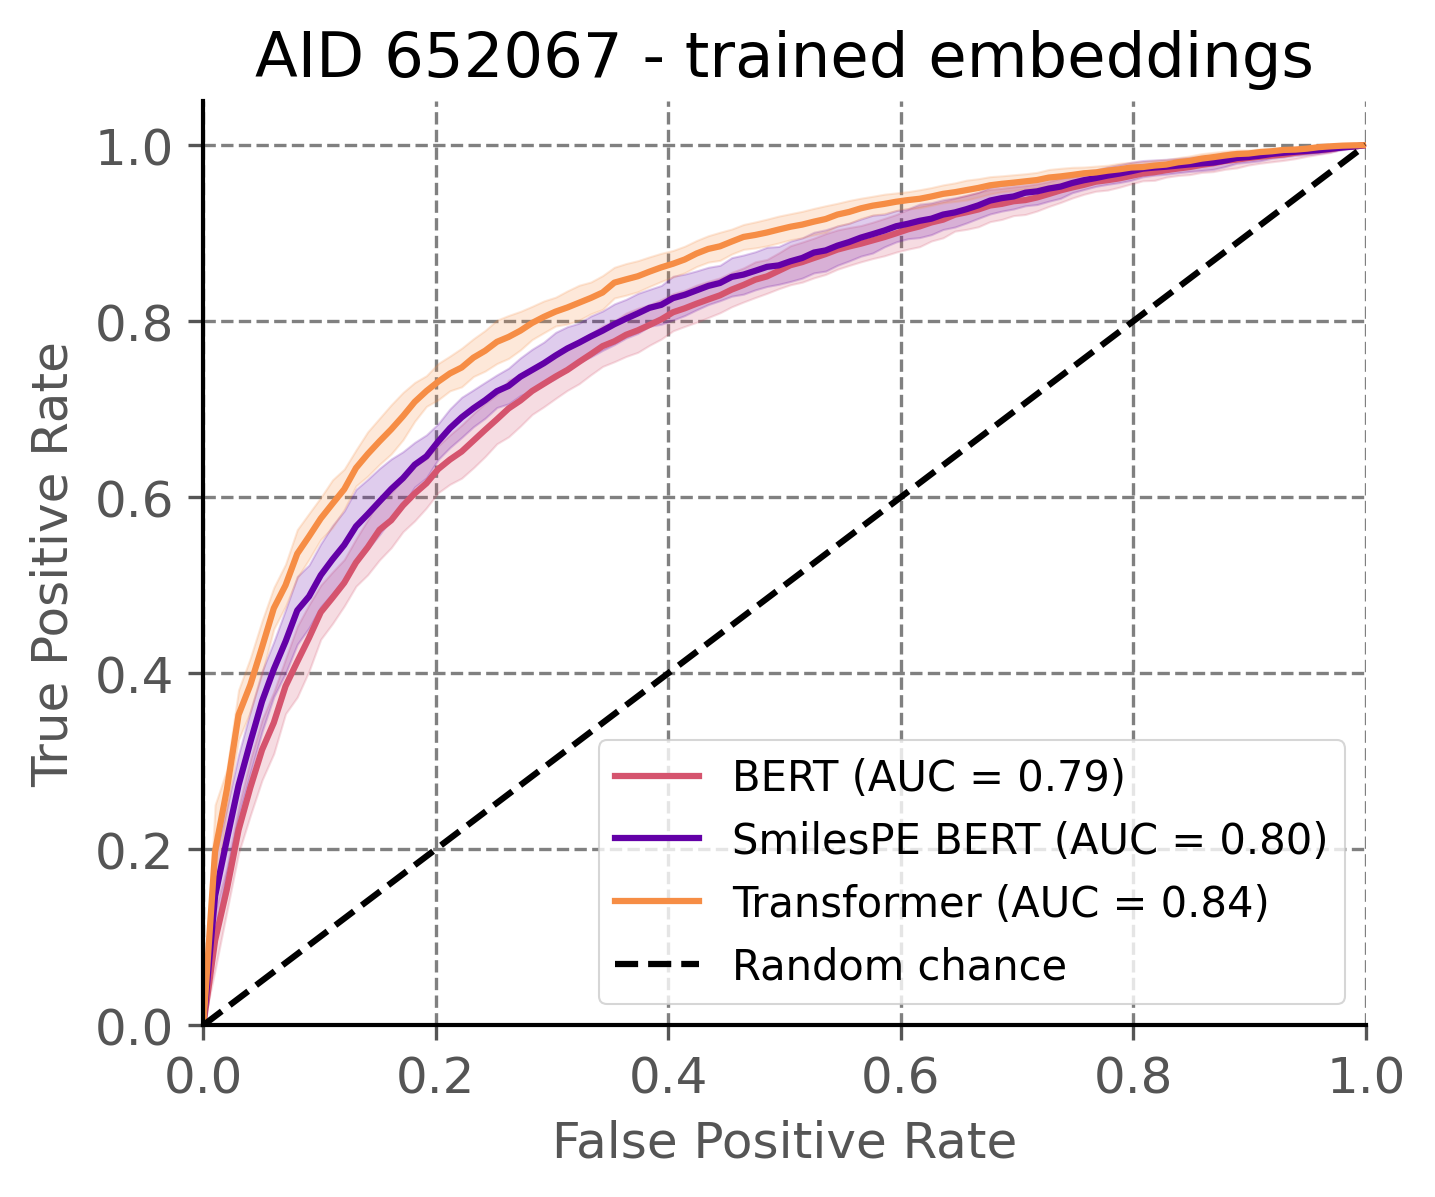

In [6]:
def process_roc(file, color, label_prefix):
    content = np.load(file)
    accs, labs, preds = content['accs'], content['labs'], content['preds']

    aucs, tprs = [], []
    mean_fpr = np.linspace(0, 1, 100)

    for fold in range(10):
        labs_k = labs[0][fold]#[0,:]
        preds_k = preds[0][fold]#[0,:]
        fpr, tpr, _ = roc_curve(labs_k, preds_k)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(labs_k, preds_k))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(mean_fpr, mean_tpr, color=color, label=f'{label_prefix} (AUC = {mean_auc:.2f})')
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

# Plotting ROC curves for both files
my_dpi = 300
plt.figure(figsize=(1500/my_dpi, 1200/my_dpi), dpi=my_dpi)

palette = sns.color_palette("plasma", 10)

process_roc("Experiments_results/res_bert_652067.npz", 
            color=palette[5], label_prefix='BERT')
process_roc("Experiments_results/res_bert_spe_652067.npz", 
            color=palette[1], label_prefix='SmilesPE BERT')
process_roc("Experiments_results/res_transformer_652067.npz", 
            color=palette[7], label_prefix='Transformer')


plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AID 652067 - trained embeddings', fontsize = 15)
plt.legend(loc='lower right', prop={'size': 10})
plt.tick_params(axis='both', which='major', labelsize=12)

plt.show()

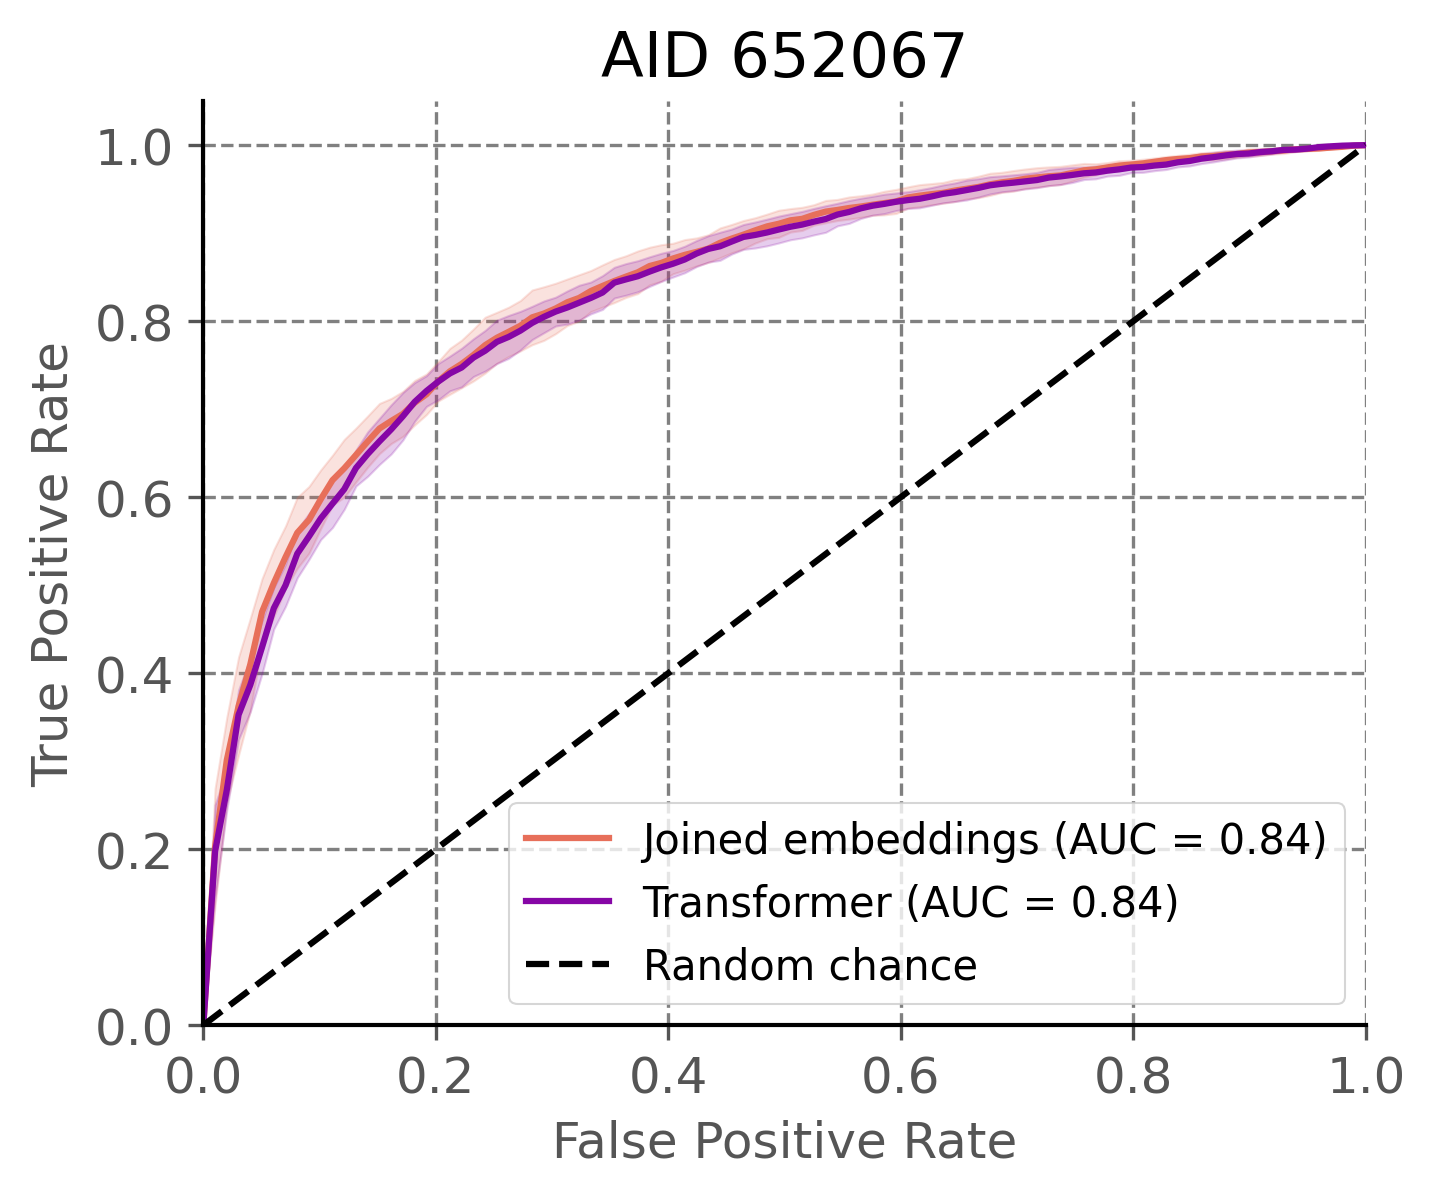

In [7]:
def process_roc(file, color, label_prefix):
    content = np.load(file)
    accs, labs, preds = content['accs'], content['labs'], content['preds']

    aucs, tprs = [], []
    mean_fpr = np.linspace(0, 1, 100)

    for fold in range(10):
        labs_k = labs[0][fold]#[0,:]
        preds_k = preds[0][fold]#[0,:]
        fpr, tpr, _ = roc_curve(labs_k, preds_k)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(labs_k, preds_k))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(mean_fpr, mean_tpr, color=color, label=f'{label_prefix} (AUC = {mean_auc:.2f})')
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

# Plotting ROC curves for both files
my_dpi = 300
plt.figure(figsize=(1500/my_dpi, 1200/my_dpi), dpi=my_dpi)

palette = sns.color_palette("plasma", 10)

process_roc("Experiments_results/res_joint_652067.npz", 
            color=palette[6], label_prefix='Joined embeddings')
process_roc("Experiments_results/res_transformer_652067.npz", 
            color=palette[2], label_prefix='Transformer')


plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AID 652067', fontsize = 15)
plt.legend(loc='lower right', prop={'size': 10})
plt.tick_params(axis='both', which='major', labelsize=12)

plt.show()

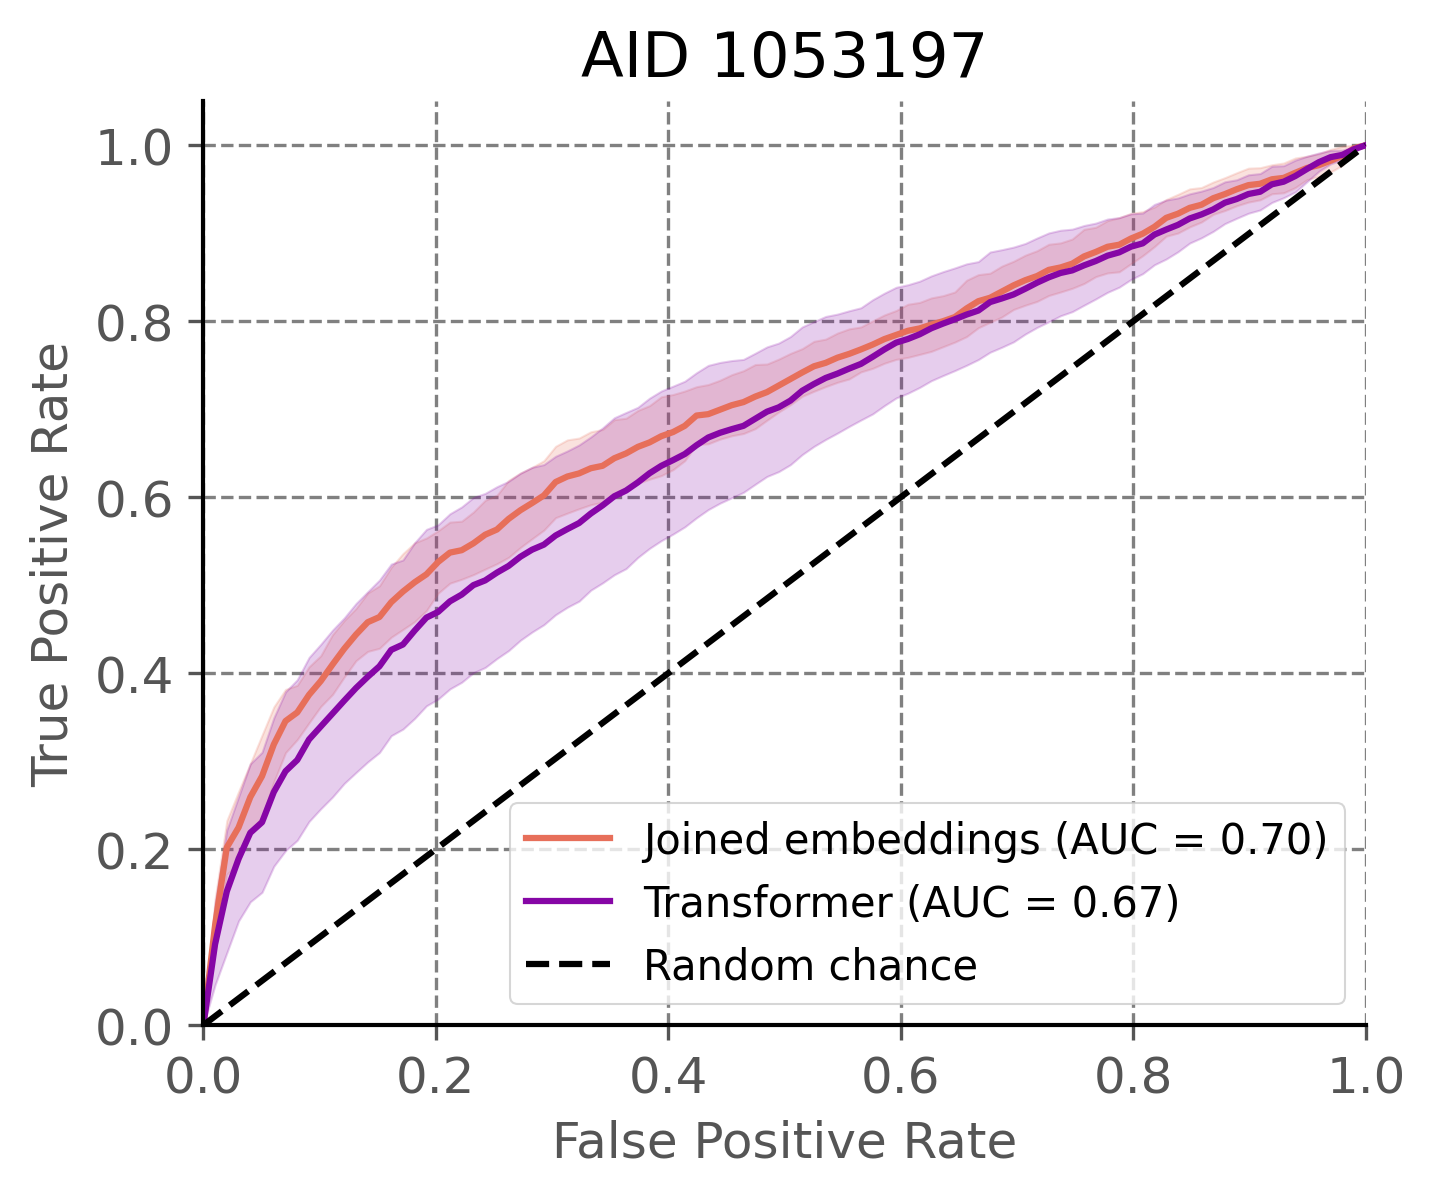

In [8]:
def process_roc(file, color, label_prefix):
    content = np.load(file)
    accs, labs, preds = content['accs'], content['labs'], content['preds']

    aucs, tprs = [], []
    mean_fpr = np.linspace(0, 1, 100)

    for fold in range(10):
        labs_k = labs[0][fold]#[0,:]
        preds_k = preds[0][fold]#[0,:]
        fpr, tpr, _ = roc_curve(labs_k, preds_k)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(labs_k, preds_k))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(mean_fpr, mean_tpr, color=color, label=f'{label_prefix} (AUC = {mean_auc:.2f})')
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

# Plotting ROC curves for both files
my_dpi = 300
plt.figure(figsize=(1500/my_dpi, 1200/my_dpi), dpi=my_dpi)

palette = sns.color_palette("plasma", 10)

process_roc("Experiments_results/res_joint_1053197.npz", 
            color=palette[6], label_prefix='Joined embeddings')
process_roc("Experiments_results/res_transformer_1053197.npz", 
            color=palette[2], label_prefix='Transformer')


plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AID 1053197', fontsize = 15)
plt.legend(loc='lower right', prop={'size': 10})
plt.tick_params(axis='both', which='major', labelsize=12)

plt.show()

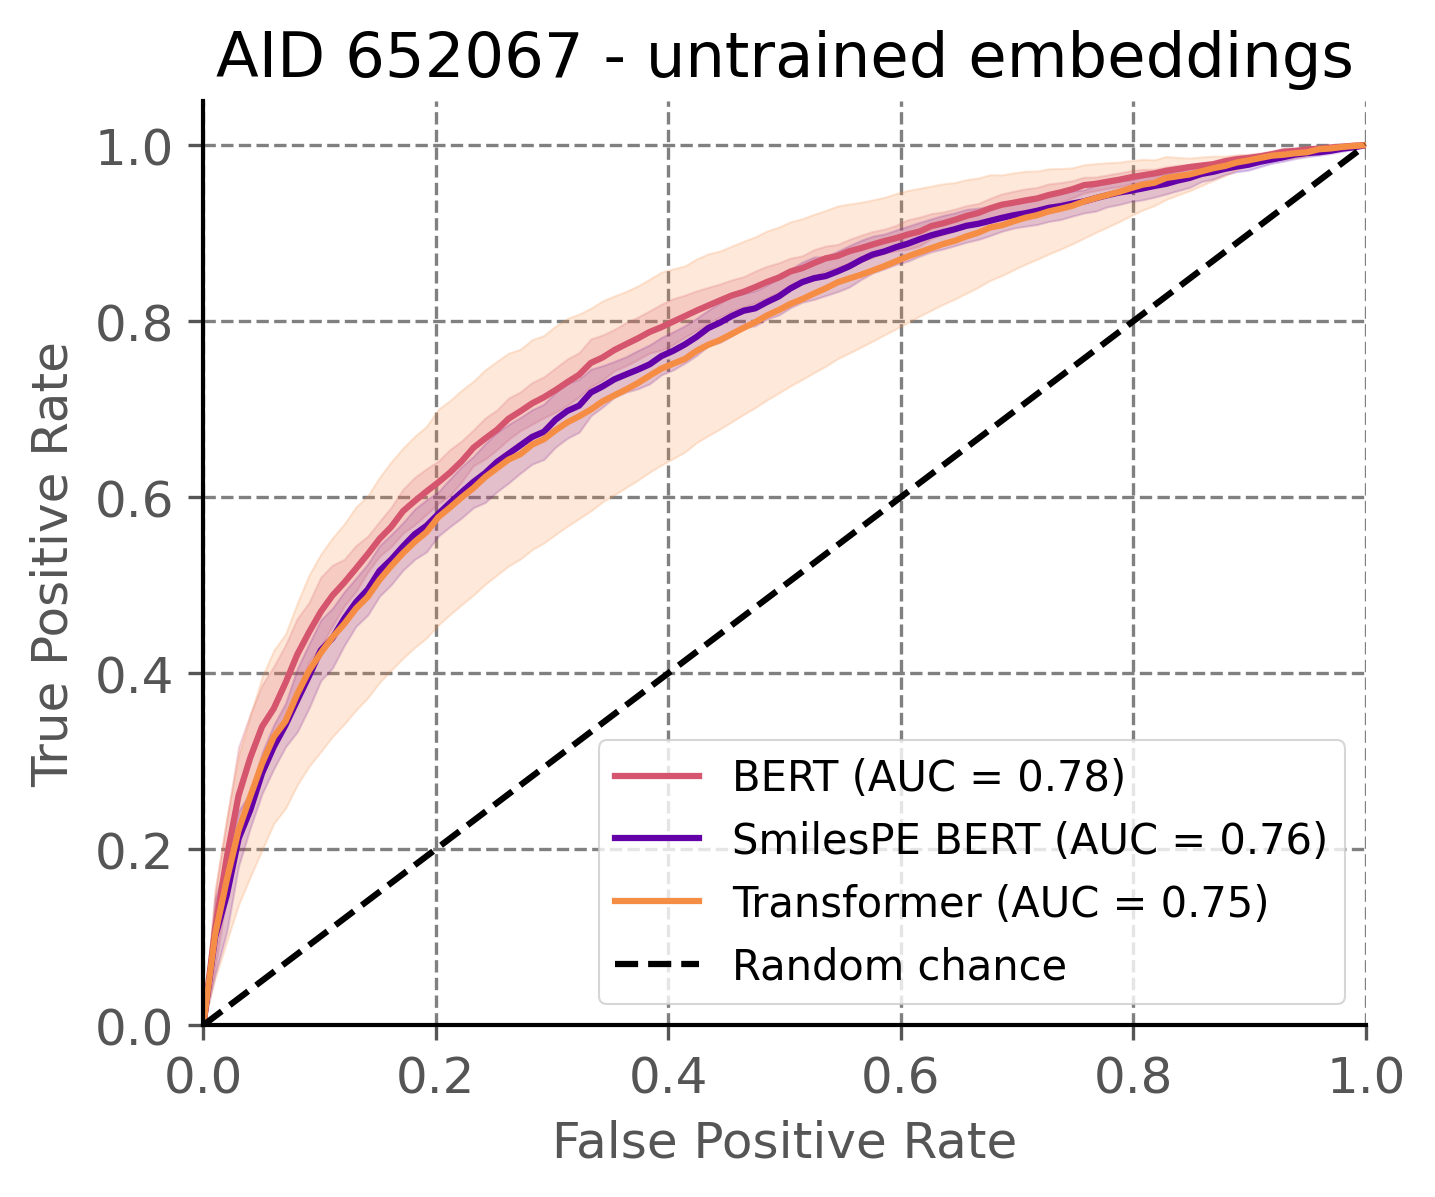

In [9]:
def process_roc(file, color, label_prefix):
    content = np.load(file)
    accs, labs, preds = content['accs'], content['labs'], content['preds']

    aucs, tprs = [], []
    mean_fpr = np.linspace(0, 1, 100)

    for fold in range(10):
        labs_k = labs[0][fold]#[0,:]
        preds_k = preds[0][fold]#[0,:]
        fpr, tpr, _ = roc_curve(labs_k, preds_k)
        interp_tpr = np.interp(mean_fpr, fpr, tpr)
        interp_tpr[0] = 0.0
        tprs.append(interp_tpr)
        aucs.append(roc_auc_score(labs_k, preds_k))

    mean_tpr = np.mean(tprs, axis=0)
    mean_tpr[-1] = 1.0
    mean_auc = auc(mean_fpr, mean_tpr)

    std_tpr = np.std(tprs, axis=0)
    tprs_upper = np.minimum(mean_tpr + std_tpr, 1)
    tprs_lower = np.maximum(mean_tpr - std_tpr, 0)

    plt.plot(mean_fpr, mean_tpr, color=color, label=f'{label_prefix} (AUC = {mean_auc:.2f})')
    plt.fill_between(mean_fpr, tprs_lower, tprs_upper, color=color, alpha=0.2)

# Plotting ROC curves for both files
my_dpi = 300
plt.figure(figsize=(1500/my_dpi, 1200/my_dpi), dpi=my_dpi)

palette = sns.color_palette("plasma", 10)

process_roc("Experiments_results/res_bert_652067_untrained.npz", 
            color=palette[5], label_prefix='BERT')
process_roc("Experiments_results/res_bert_spe_652067_untrained.npz", 
                color=palette[1], label_prefix='SmilesPE BERT')
process_roc("Experiments_results/res_transformer_652067_untrained.npz", 
                color=palette[7], label_prefix='Transformer')

plt.plot([0, 1], [0, 1], linestyle='--', color='black', label='Random chance')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('AID 652067 - untrained embeddings', fontsize = 15)
plt.legend(loc='lower right', prop={'size': 10})
plt.tick_params(axis='both', which='major', labelsize=12)

plt.show()